# 2일차 4교시 실습 · 동전 개수 세기와 오류 분석

강의자료 PDF의 7·8·9쪽을 보고 빈칸 세 곳을 채웁니다. 압축을 모두 해제한 뒤 위에서부터 실행합니다. `helpers.py`의 함수는 제공 함수입니다. OpenCV 내장 함수와 구분합니다.

기본 이미지: 원본 coins의 x0:384, y150:303 영역. 좌표는 이 ROI 기준입니다. 별도 사진은 다른 입력이며 후보 ID도 새로 부여합니다. 정답은 사람이 지정한 기본 사진 12개, 별도 사진 10개입니다.


In [ ]:
# 자동차의 외곽선이 중요할까..? 
# -> 웨이모 같은 회사에서는 네모형태로, 사각형 형태로 바운딩 박스로 데이터를 정의한다.
# 외곽선 기준으로 가장 먼곳을 향한것을 기준으로 바운딩박스 형태로 나오게 됨. boundingRect

import csv
import json
from pathlib import Path
import matplotlib.pyplot as plt
from helpers import load_gray, extract_candidates, select_candidates, draw_selected
import cv2

def show_result(gray, selected, title):
    result = draw_selected(gray, selected)
    plt.figure(figsize=(10, 4))
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()
    return result

gray = load_gray('images/base.png')
mask, candidates, threshold = extract_candidates(gray)
area_min, area_max, circularity_min = 900, 3500, 0.55


## 전체 사진의 후보 · 강의자료 PDF 3~4쪽
기본 ROI와 구분합니다. 사람이 확인한 전체 사진의 동전은 24개입니다. 면적 조건만 적용해도 모든 오류가 해결되지는 않습니다.


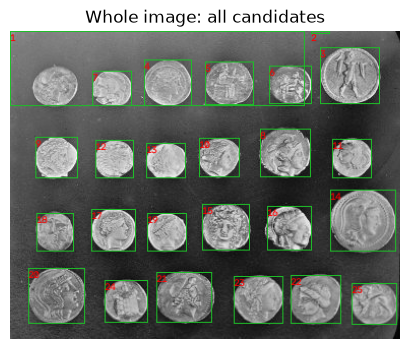

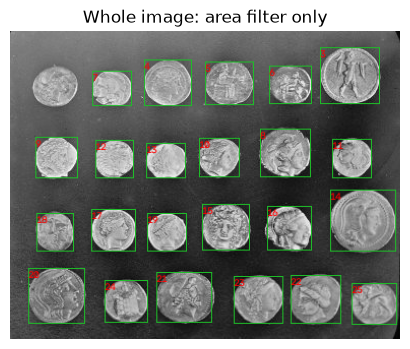

전체 사진 후보: 25
면적 조건 통과: 23


In [2]:
full_gray = load_gray('images/full.png')
full_mask, full_candidates, full_threshold = extract_candidates(full_gray)
full_area_selected = [item for item in full_candidates if 900 <= item['area'] <= 3500]
show_result(full_gray, full_candidates, 'Whole image: all candidates')
show_result(full_gray, full_area_selected, 'Whole image: area filter only')
print('전체 사진 후보:', len(full_candidates))
print('면적 조건 통과:', len(full_area_selected))


## A · 조건 결합 · 강의자료 PDF 7쪽
면적과 원형도 조건을 모두 만족하도록 채웁니다.


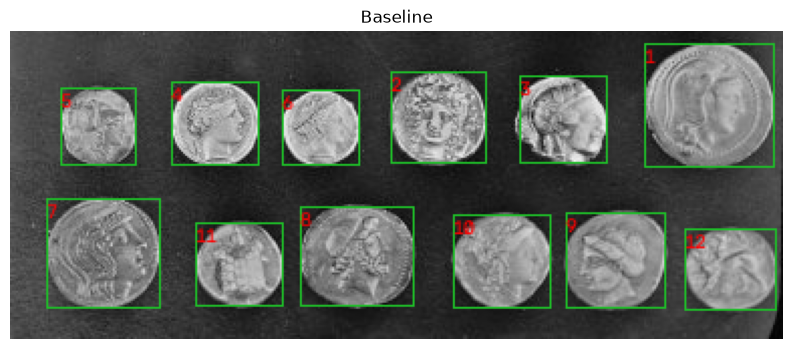

In [10]:
selected = []
for item in candidates:
    if item['perimeter'] <= 0:
        continue
    area_ok = area_min <= item['area'] <= area_max
    circularity_ok = item['circularity'] >= circularity_min
    if area_ok and circularity_ok:
        selected.append(item)
base_result = show_result(gray, selected, 'Baseline')


## B · 선택 개수 · 강의자료 PDF 8쪽
기본 조건의 선택 개수를 구합니다. 후보 ID의 최댓값과 구분합니다.


In [11]:
coin_count = len(selected)
print('기본 조건의 선택 개수:', coin_count)


기본 조건의 선택 개수: 12


## C · 면적 하한 변경 · 강의자료 PDF 9쪽
강의자료 PDF 오른쪽 비교 결과의 면적 하한을 입력합니다. 상한과 원형도 기준은 고정합니다.


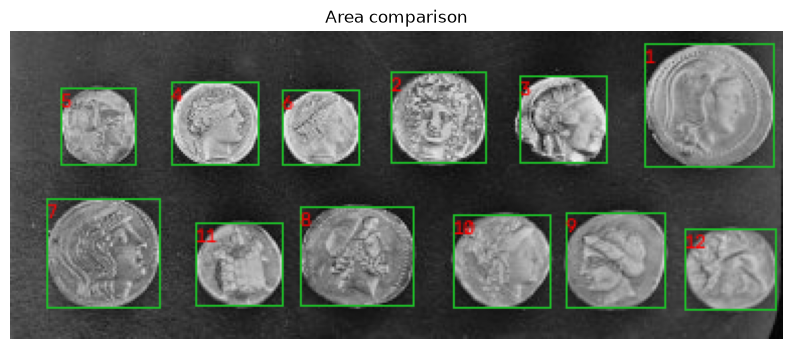

선택 개수: 12


In [12]:
area_min_compare = coin_count
area_selected = select_candidates(candidates, area_min_compare, 3500, 0.55)
show_result(gray, area_selected, 'Area comparison')
print('선택 개수:', len(area_selected))


## Circularity 비교 · 강의자료 PDF 10~11쪽
면적 범위는 고정하고 원형도 하한만 바꿉니다.


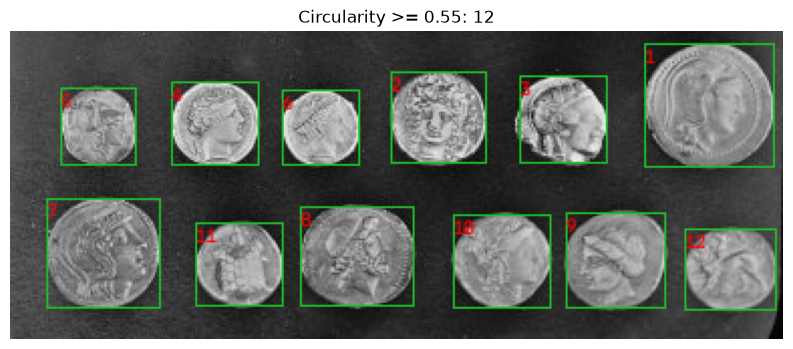

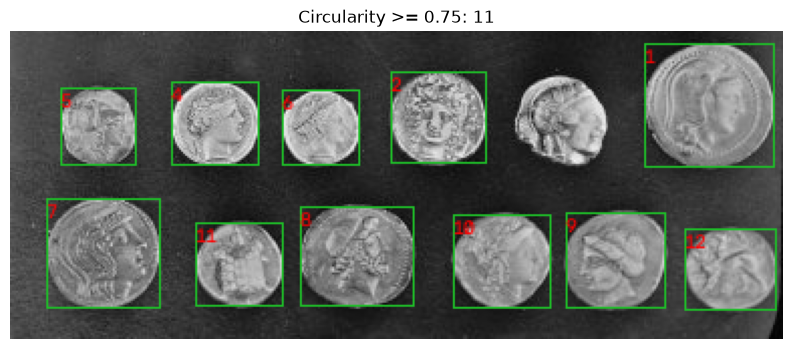

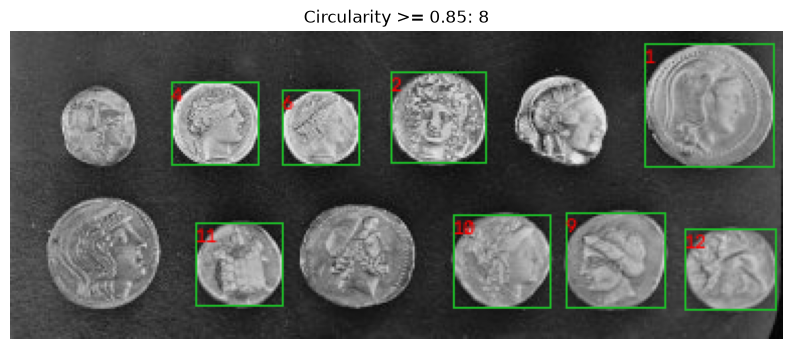

In [6]:
for minimum in (0.55, 0.75, 0.85):
    current = select_candidates(candidates, 900, 3500, minimum)
    show_result(gray, current, f'Circularity >= {minimum}: {len(current)}')


## 다른 사진 · 강의자료 PDF 16~18쪽
전처리 절차와 선택 기준을 유지합니다. Otsu가 반환하는 값은 각 이미지에서 자동 결정됩니다. 사람이 확인한 정답은 10개입니다.


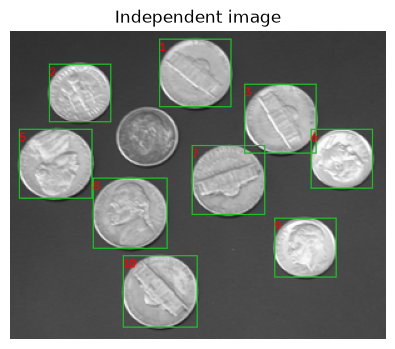

다른 사진 선택 개수: 9


In [7]:
other_gray = load_gray('images/independent.png')
other_mask, other_candidates, other_threshold = extract_candidates(other_gray)
other_selected = select_candidates(other_candidates, 900, 3500, 0.55)
other_result = show_result(other_gray, other_selected, 'Independent image')
print('다른 사진 선택 개수:', len(other_selected))


## 결과와 선택 근거 저장 · 강의자료 PDF 18쪽
각 사진의 PNG·후보별 CSV·설정 JSON을 저장합니다. 별도 사진은 기준을 수정하지 않은 결과입니다.


In [13]:
output_dir = Path('results')
output_dir.mkdir(exist_ok=True)
for name, image, items, chosen, otsu in [
    ('base', base_result, candidates, selected, threshold),
    ('independent', other_result, other_candidates, other_selected, other_threshold)
]:
    cv2.imencode('.png', image)[1].tofile(output_dir / f'{name}.png')
    selected_ids = {item['id'] for item in chosen}
    with (output_dir / f'{name}_candidates.csv').open('w', newline='', encoding='utf-8-sig') as file:
        writer = csv.writer(file)
        writer.writerow(['id', 'area_pixel2', 'perimeter_pixel', 'circularity', 'selected', 'reason'])
        for item in items:
            reasons = []
            if not 900 <= item['area'] <= 3500:
                reasons.append('area')
            if item['perimeter'] <= 0:
                reasons.append('zero_perimeter')
            elif item['circularity'] < 0.55:
                reasons.append('circularity')
            writer.writerow([item['id'], item['area'], item['perimeter'], item['circularity'],
                             item['id'] in selected_ids, '+'.join(reasons) or 'pass'])
    config = dict(area_min=900, area_max=3500, circularity_min=0.55,
                  otsu_return_value=otsu, selected_count=len(chosen))
    (output_dir / f'{name}_settings.json').write_text(json.dumps(config, indent=2), encoding='utf-8')


## 사례 · 크기 변화 · 강의자료 PDF 15쪽
같은 사진을 축소한 가공 비교입니다. 독립 촬영 사진이 아닙니다.


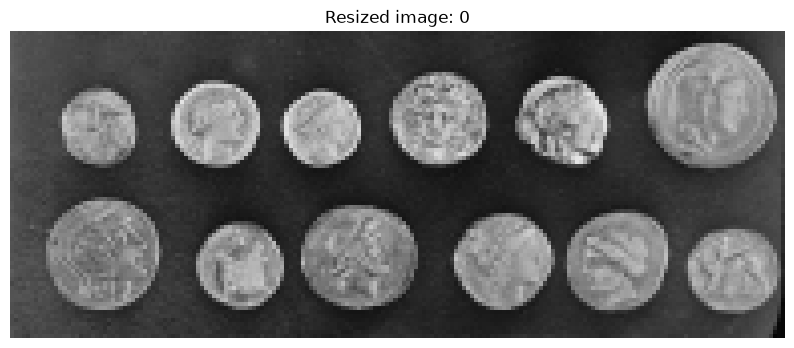

array([[[89, 89, 89],
        [88, 88, 88],
        [80, 80, 80],
        ...,
        [68, 68, 68],
        [68, 68, 68],
        [71, 71, 71]],

       [[90, 90, 90],
        [84, 84, 84],
        [83, 83, 83],
        ...,
        [69, 69, 69],
        [68, 68, 68],
        [68, 68, 68]],

       [[90, 90, 90],
        [87, 87, 87],
        [82, 82, 82],
        ...,
        [70, 70, 70],
        [67, 67, 67],
        [71, 71, 71]],

       ...,

       [[82, 82, 82],
        [81, 81, 81],
        [76, 76, 76],
        ...,
        [41, 41, 41],
        [ 8,  8,  8],
        [ 7,  7,  7]],

       [[84, 84, 84],
        [72, 72, 72],
        [74, 74, 74],
        ...,
        [18, 18, 18],
        [ 9,  9,  9],
        [ 6,  6,  6]],

       [[83, 83, 83],
        [73, 73, 73],
        [73, 73, 73],
        ...,
        [ 4,  4,  4],
        [ 8,  8,  8],
        [ 7,  7,  7]]], shape=(76, 192, 3), dtype=uint8)

In [14]:
small = cv2.resize(gray, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)
small_mask, small_candidates, _ = extract_candidates(small)
small_selected = select_candidates(small_candidates, 900, 3500, 0.55)
show_result(small, small_selected, f'Resized image: {len(small_selected)}')
